# Multi-UAV Swarm Trajectory Planning

**Pipeline overview**

| Cell | Stage | Modules |
|------|-------|---------|
| 1 | Environment setup & validation | `environment`, `visualizer_static` |
| 2 | Global path planning (A\*) | `global_planner` |
| 3 | Safe corridor extraction | `safe_corridor` |
| 4 | Individual trajectory generation (STO) | `trajectory_generator` |
| 5 | Conflict detection | `conflict_resolver` |
| 6 | Conflict resolution & replanning | `conflict_resolver` |
| 7 | Static 3-D visualisation | `visualizer_static` |
| 8 | Web simulation (HTML export) | `visualizer_web` |

In [1]:
# ── Cell 1 — Environment + Fleet setup ──────────────────────────────────────
import os, sys, logging

# ── sys.path setup ────────────────────────────────────────────────────────────
_SWARM_DIR  = os.path.abspath('')          # …/uavsafeplanning/SWARM
_PARENT_DIR = os.path.dirname(_SWARM_DIR)  # …/uavsafeplanning
for _p in (_SWARM_DIR, _PARENT_DIR):
    if _p not in sys.path:
        sys.path.insert(0, _p)

# ── Imports ───────────────────────────────────────────────────────────────────
from environment       import Environment, ConfigValidationError
from uav               import Fleet
from visualizer_static import plot_environment_3d

# Silence sub-module DEBUG/INFO — only warnings/errors reach the output.
# Must come AFTER imports so the handlers are already registered.
for _mod in ('environment', 'uav'):
    logging.getLogger(_mod).setLevel(logging.WARNING)

# ── Config paths ──────────────────────────────────────────────────────────────
ENV_CONFIG   = os.path.join(_SWARM_DIR, 'configs', 'environment.yaml')
FLEET_CONFIG = os.path.join(_SWARM_DIR, 'configs', 'fleet.yaml')

def _tag(ok): return '✓' if ok else '✗'

# ── Environment ───────────────────────────────────────────────────────────────
try:
    env        = Environment.from_yaml(ENV_CONFIG)
    voxel_grid = env.to_voxel_grid()   # cached — A* (Cell 2) reuses this
    w = env.world
    print(f"✓  Environment  [{os.path.basename(ENV_CONFIG)}]  "
          f"{len(env.cylinders)} cylinders · {len(env.walls)} walls · "
          f"grid {w.nx}×{w.ny}×{w.nz}")
except ConfigValidationError as exc:
    print(f"✗  Environment  [{os.path.basename(ENV_CONFIG)}]  FAILED → {exc}")
    raise

# ── Fleet ─────────────────────────────────────────────────────────────────────
try:
    fleet = Fleet.from_yaml(FLEET_CONFIG)
    ids   = ', '.join(u.id for u in fleet.uavs)
    print(f"✓  Fleet        [{os.path.basename(FLEET_CONFIG)}]  "
          f"{len(fleet.uavs)} UAVs  ({ids})")
except ConfigValidationError as exc:
    print(f"✗  Fleet        [{os.path.basename(FLEET_CONFIG)}]  FAILED → {exc}")
    raise

# ── Position validation ───────────────────────────────────────────────────────
try:
    fleet.validate_with_environment(env)
    print("✓  Positions    all start / goal positions are obstacle-free")
except ConfigValidationError as exc:
    print(f"✗  Positions    FAILED → {exc}")
    raise

# ── Visualisation ─────────────────────────────────────────────────────────────
plot_environment_3d(env, fleet=fleet)


✓  Environment  [environment.yaml]  4 cylinders · 2 walls · grid 100×100×40
✓  Fleet        [fleet.yaml]  3 UAVs  (uav_0, uav_1, uav_2)
✓  Positions    all start / goal positions are obstacle-free


In [2]:
# ── Cell 2 — Global Path Planning (A*) ──────────────────────────────────────
from global_planner import plan_paths, PlanResult, PlannerConfig
import logging
logging.getLogger("global_planner").setLevel(logging.WARNING)

PLANNER_CONFIG = os.path.join(_SWARM_DIR, "configs", "planner.yaml")

# ── Load planner config ───────────────────────────────────────────────────────
try:
    planner_cfg = PlannerConfig.from_yaml(PLANNER_CONFIG)
    w = env.world
    print(f"✓  Planner      [{os.path.basename(PLANNER_CONFIG)}]  "
          f"connectivity={planner_cfg.connectivity}  clearance={planner_cfg.clearance} voxel  "
          f"inflation={planner_cfg.inflation_radius} m")
except Exception as exc:
    print(f"✗  Planner      [{os.path.basename(PLANNER_CONFIG)}]  FAILED → {exc}")
    raise

# ── Apply obstacle inflation (rebuilds voxel grid if radius changed) ──────────
env.inflation_radius = planner_cfg.inflation_radius

# ── Run A* for all UAVs ───────────────────────────────────────────────────────
print(f"Running A* for {len(fleet.uavs)} UAVs  "
      f"(grid {env.world.nx}×{env.world.ny}×{env.world.nz})")

try:
    paths = plan_paths(env, fleet,
                       connectivity=planner_cfg.connectivity,
                       clearance=planner_cfg.clearance)
    for pr in paths:
        print(f"  ✓  {pr.uav_id:<10}  A*: {pr.n_astar_nodes:4d} nodes  "
              f"→  LOS: {pr.n_waypoints} waypoints  →  {pr.path_length:.1f} m")
except RuntimeError as exc:
    print(f"  ✗  A* FAILED — {exc}")
    raise

# ── Visualisation — same scene as Cell 1 + pruned paths ──────────────────────
plot_environment_3d(env, fleet=fleet, paths=paths)

✓  Planner      [planner.yaml]  connectivity=18  clearance=0 voxel  inflation=0.5 m
Running A* for 3 UAVs  (grid 100×100×40)
  ✓  uav_0       A*:   97 nodes  →  LOS: 7 waypoints  →  58.8 m
  ✓  uav_1       A*:   89 nodes  →  LOS: 2 waypoints  →  44.0 m
  ✓  uav_2       A*:   95 nodes  →  LOS: 5 waypoints  →  58.2 m


In [3]:
# ── Cell 3 — Safe Corridor Extraction ────────────────────────────────────────
from safe_corridor import extract_corridors, CorridorResult
import logging
logging.getLogger("safe_corridor").setLevel(logging.WARNING)

BOX_HE = planner_cfg.box_half_extents   # loaded from planner.yaml

print(f"Extracting safe corridors  "
      f"(seed box: {BOX_HE[0]} × {BOX_HE[1]} × {BOX_HE[2]} m)")

try:
    corridors = extract_corridors(env, paths, box_half_extents=BOX_HE)
    for cr in corridors:
        n     = len(cr.A_list)
        avg_c = (sum(cr.A_list[i].shape[0] for i in range(n)) / n) if n else 0
        print(f"  ✓  {cr.uav_id:<10}  {n} corridor{'s' if n != 1 else ' '}  "
              f"({avg_c:.0f} constraints/corridor avg)")
except RuntimeError as exc:
    print(f"  ✗  FAILED — {exc}")
    raise

# ── Visualisation — environment + paths + safe corridors ─────────────────────
plot_environment_3d(env, fleet=fleet, paths=paths, corridors=corridors)

Extracting safe corridors  (seed box: 5.0 × 5.0 × 5.0 m)
  ✓  uav_0       6 corridors  (10 constraints/corridor avg)
  ✓  uav_1       1 corridor   (14 constraints/corridor avg)
  ✓  uav_2       4 corridors  (10 constraints/corridor avg)


In [4]:
# ── Cell 4 — Trajectory Generation (STO) ────────────────────────────────────
from trajectory_generator import generate_trajectories, TrajectoryResult, STOConfig
import logging
logging.getLogger("trajectory_generator").setLevel(logging.WARNING)

sto_cfg = STOConfig.from_yaml(PLANNER_CONFIG)
print(f"✓  STO config   [{os.path.basename(PLANNER_CONFIG)}]  "
      f"max_iter={sto_cfg.max_iter}  adaptive={sto_cfg.adaptive_weights}  "
      f"cost={sto_cfg.corridor_cost_type.upper()}")

# ── Optimise trajectories (runs STO per UAV) ─────────────────────────────────
try:
    trajectories = generate_trajectories(fleet, paths, corridors, sto_cfg, verbose=True)
except RuntimeError as exc:
    print(f"\n✗  STO FAILED — {exc}")
    raise

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'─'*62}")
for tr in trajectories:
    print(f"  ✓  {tr.uav_id:<10}  "
          f"T={tr.total_time:.1f} s  "
          f"max_v={tr.vel_norm.max():.2f} m/s  "
          f"jerk={tr.jerk_cost:.4f}  "
          f"viol_corr={tr.violations['corridor']:.4f}  "
          f"({tr.runtime:.0f} s)")
print(f"{'─'*62}")

# ── Visualisation — environment + paths + corridors + trajectories ────────────
plot_environment_3d(env, fleet=fleet, paths=paths, corridors=corridors,
                    trajectories=trajectories)

✓  STO config   [planner.yaml]  max_iter=50  adaptive=True  cost=L2

──────────────────────────────────────────────────────────────
  STO  ▶  uav_0   (6 segments,  5 waypoints)
──────────────────────────────────────────────────────────────


/home/okanarif/repositories/CopySemesterThesis/uavsafeplanning/STO/sto_planner.py:146: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.waypoints = torch.tensor([waypoints_init], dtype=torch.float32, requires_grad=True)


STO TRAJECTORY OPTIMIZATION
Segments:       6
Waypoints:      5
Max iterations: 50
Corridor cost:  L2 penalty
Adaptive weights: ON  (3 phases, ×5.0 per phase)

Objective weights (fixed):
  λ_jerk     = 10.00
  λ_time     = 0.05

Constraint weights (phase 1 / final target):
  λ_vel      = 4.80  →  120.00
  λ_acc      = 0.20  →  5.00
  λ_corridor = 40.00  →  1000.00  [L2]

Iter | Phase |        Total |       Jerk |     Time |        Vel |        Acc |       Corr
--------------------------------------------------------------------------------------------------
   1 |     1 |   132.173447 |  13.133270 |    16.37 |   0.004656 |   0.000000 |   0.000000
   5 |     1 |     2.882928 |   0.052404 |    46.89 |   0.000000 |   0.000000 |   0.000362
  10 |     1 |     2.882928 |   0.052404 |    46.89 |   0.000000 |   0.000000 |   0.000362
  15 |     1 |     2.882928 |   0.052404 |    46.89 |   0.000000 |   0.000000 |   0.000362

  ── Phase 2/3: λ_vel=24.0  λ_acc=1.0  λ_corridor=200.0  (L-BFGS reset)

OK  Conflict detector  [planner.yaml]  safety_margin=0.000 m  dt_sample=50 ms

──────────────────────────────────────────────────────────────────────
  SPACE-TIME CONFLICT DETECTION REPORT
──────────────────────────────────────────────────────────────────────
  Safety margin (extra)   : 0.000 m  (threshold = r_i + r_j + margin)
  Time-grid resolution    : 50 ms
──────────────────────────────────────────────────────────────────────
  OK  No trajectory separation violations detected.
──────────────────────────────────────────────────────────────────────
  Corridor polytope spatial intersections : 15
  -> with simultaneous temporal overlap   : 7

  [!] [uav_0 P2] x [uav_1 P0]   A:[13.18-22.28 s]   B:[0.00-16.37 s]  <- SPATIO-TEMPORAL CONFLICT
  [ ] [uav_0 P3] x [uav_1 P0]   A:[22.12-27.14 s]   B:[0.00-16.37 s]
  [ ] [uav_0 P4] x [uav_1 P0]   A:[25.88-39.22 s]   B:[0.00-16.37 s]
  [!] [uav_0 P2] x [uav_2 P0]   A:[13.18-22.28 s]   B:[0.00-20.49 s]  <- SPATIO-TEMPORAL CONFLICT
  [!] [uav_0 P

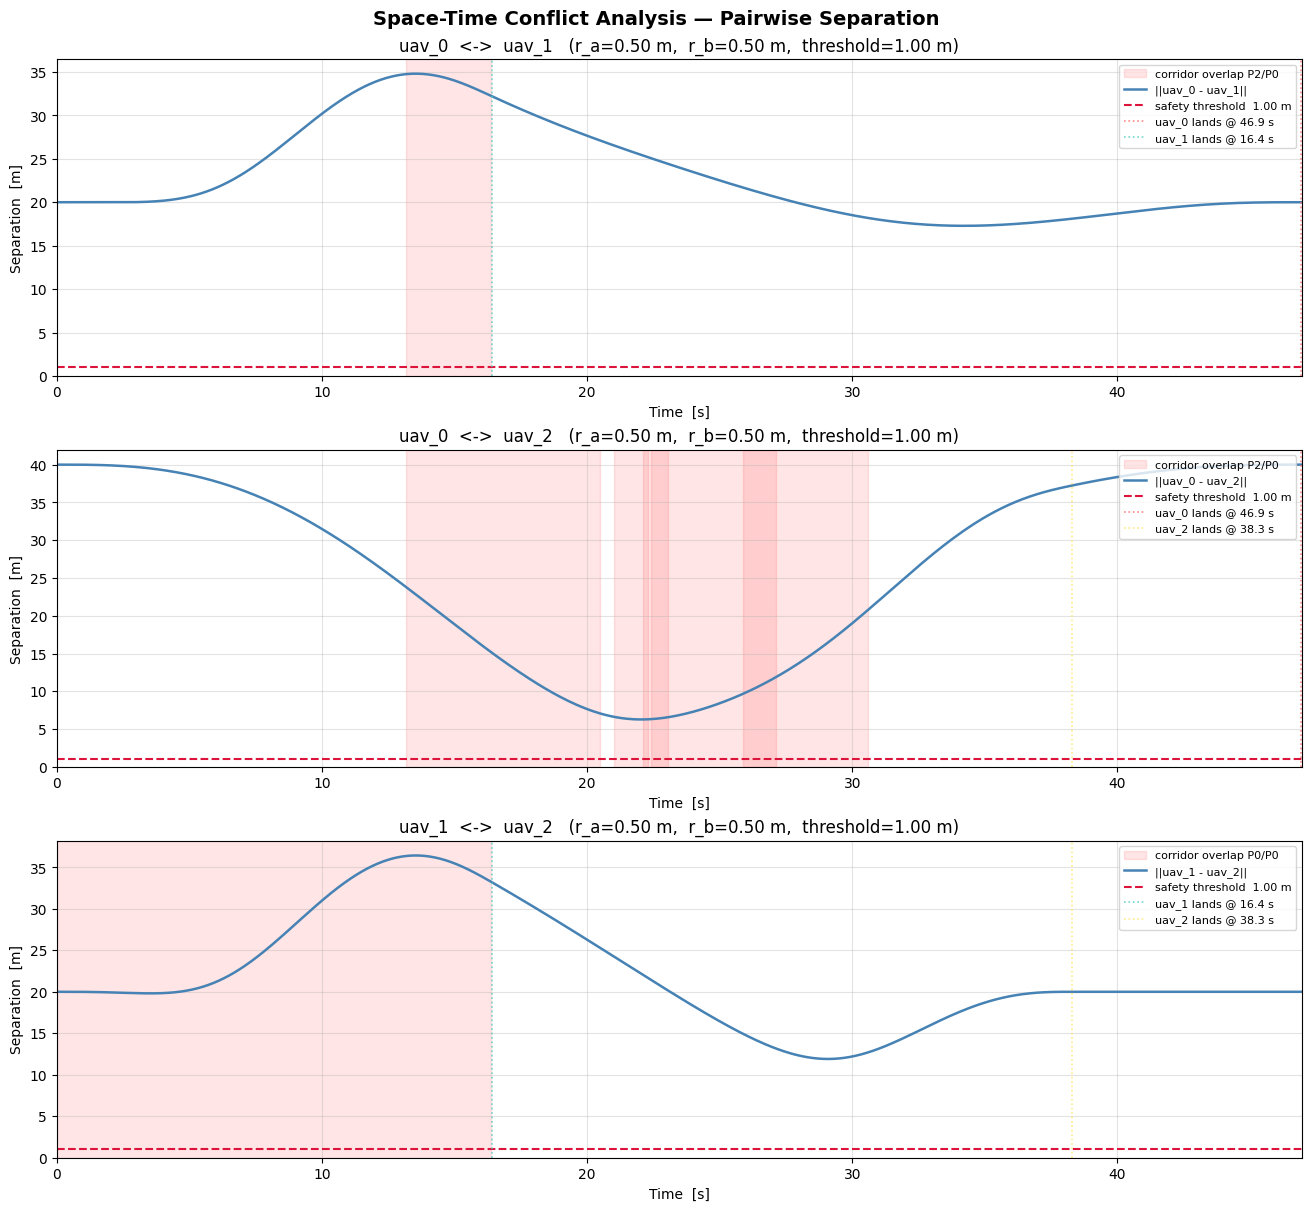

In [5]:
# ── Cell 5 — Space-Time Conflict Detection ───────────────────────────────────
from conflict_detector import (
    ConflictDetectorConfig,
    detect_conflicts,
    plot_conflict_report,
)
import logging
logging.getLogger("conflict_detector").setLevel(logging.WARNING)

# ── Load config from planner.yaml (conflict_detection: block) ────────────────
cd_cfg = ConflictDetectorConfig.from_yaml(PLANNER_CONFIG)
print(
    f"OK  Conflict detector  [{os.path.basename(PLANNER_CONFIG)}]  "
    f"safety_margin={cd_cfg.safety_margin:.3f} m  "
    f"dt_sample={cd_cfg.dt_sample * 1000:.0f} ms"
)

# ── Run detection ─────────────────────────────────────────────────────────────
conflict_report = detect_conflicts(
    fleet        = fleet,
    trajectories = trajectories,
    corridors    = corridors,
    cfg          = cd_cfg,
)

# ── Report ────────────────────────────────────────────────────────────────────
print()
print(conflict_report.summary())

# ── Visualisation ─────────────────────────────────────────────────────────────
plot_conflict_report(
    report       = conflict_report,
    fleet        = fleet,
    trajectories = trajectories,
)

In [6]:
# ── Cell 6 — Trajectory Simulation (Animated HTML) ───────────────────────────
from visualizer_simulation import SimulationConfig, simulate_trajectories
import logging
logging.getLogger("visualizer_simulation").setLevel(logging.WARNING)

SIM_CONFIG = os.path.join(_SWARM_DIR, "configs", "simulation.yaml")

# ── Load simulation config ────────────────────────────────────────────────────
sim_cfg = SimulationConfig.from_yaml(SIM_CONFIG)
print(
    f"OK  Simulation config  [{os.path.basename(SIM_CONFIG)}]\n"
    f"    dt={sim_cfg.dt * 1000:.0f} ms  "
    f"trail={sim_cfg.trail_length:.1f} s  "
    f"drone_size={sim_cfg.drone_size} px  "
    f"frame_duration={sim_cfg.frame_duration_ms} ms"
)

import numpy as np
t_max    = max(tr.total_time for tr in trajectories)
n_frames = len(np.arange(0.0, t_max + sim_cfg.dt, sim_cfg.dt))
print(f"    frames={n_frames}  t_max={t_max:.1f} s  output={sim_cfg.output_html}")

# ── Build animation and export to HTML ───────────────────────────────────────
print("\nBuilding animation frames ...")
html_path = simulate_trajectories(
    env             = env,
    fleet           = fleet,
    trajectories    = trajectories,
    corridors       = corridors,
    conflict_report = conflict_report,
    cfg             = sim_cfg,
)
print(f"\nOK  Simulation exported →  {html_path}")
print("    Open the file in your browser to play the animation.")

OK  Simulation config  [simulation.yaml]
    dt=50 ms  trail=2.0 s  drone_size=10 px  frame_duration=80 ms
    frames=940  t_max=46.9 s  output=simulation.html

Building animation frames ...

OK  Simulation exported →  /home/okanarif/repositories/CopySemesterThesis/uavsafeplanning/SWARM/simulation.html
    Open the file in your browser to play the animation.
